In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade
FIXED_END = int(pd.Timestamp('2026-07-05').timestamp() * 1000)

In [3]:
def get_historical_data(symbol, interval='60', num_candles=5000, end=FIXED_END):
    
    # for live data, pass end=int(time.time() * 1000) as an argument
    
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def backtest(price_a, price_b, zscore, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    pnl_history = []

    for i in range(1, len(zscore)):
        if position == 0 and zscore[i] > 2:
            position = -1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == 0 and zscore[i] < -2:
            position = 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == -1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (entry_price_a - price_a[i])
            pnl += units_b * (price_b[i] - entry_price_b)
            pnl -= fee_rate * capital * 4
            position = 0
        elif position == 1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (price_a[i] - entry_price_a)
            pnl += units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * capital * 4
            position = 0

        pnl_history.append(pnl)

    if position != 0:
        units_a = capital / entry_price_a
        units_b = capital / entry_price_b
        pnl += position * units_a * (price_a[-1] - entry_price_a)
        pnl += position * units_b * (entry_price_b - price_b[-1])
        pnl -= fee_rate * capital * 4
        pnl_history[-1] = pnl
    return pnl_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))

    if n < 5000:
        print(f"insufficient data for {symbol_a}|{symbol_b}")
        return 
        
    price_a = price_a[:n]
    price_b = price_b[:n]

    price_a_train = price_a[:2500]
    price_b_train = price_b[:2500]
    
    _, pvalue, _ = coint(price_a_train, price_b_train)
    if pvalue > 0.05:
        print(f"not cointegrated in training period, skipping")
        return
    print(f"cointegration p-value (train): {pvalue:.4f}")
    
    beta = np.cov(price_a_train, price_b_train)[0, 1] / np.var(price_b_train, ddof=1) 
    alpha = np.mean(price_a_train) - beta * np.mean(price_b_train)
    spread_train = price_a_train - alpha - beta * price_b_train

    timestamps_test = df_a['timestamp'][2500:5000]
    price_a_test = price_a[2500:5000]
    price_b_test = price_b[2500:5000]
    spread_test = price_a_test - alpha - beta * price_b_test
    zscore = (spread_test - spread_train.mean()) / spread_train.std()

    pnl_history = backtest(price_a_test, price_b_test, zscore, capital=CAPITAL)
    days = len(price_a_test) // 24
    print(f"total pnl: ${pnl_history[-1]:.2f} over {days} days")
    print(f"daily pnl: ${pnl_history[-1]/days:.2f}/day")

    returns = np.diff(pnl_history)
    if np.std(returns) == 0:
        print("sharpe ratio undefined (no closed trades)")
    else:
        sharpe = (np.mean(returns) / np.std(returns) * np.sqrt(24 * 365))
        print(f"sharpe ratio: {sharpe:.2f}")

    peak = np.maximum.accumulate(pnl_history)
    drawdown = np.array(pnl_history) - peak
    max_dd_pct = np.min(drawdown) / (CAPITAL * 2) * 100
    print(f"max drawdown: {max_dd_pct:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps_test, price_a_test / price_a_test[0], label=symbol_a)
    axes[0, 0].plot(timestamps_test, price_b_test / price_b_test[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps_test, spread_test)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps_test, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps_test[1:], pnl_history)
    axes[1, 1].axhline(0, color='gray', linestyle=':')
    axes[1, 1].set_title('cumulative pnl')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

597
['CSPRUSDT', 'GRAMUSDT', 'SOSOUSDT', 'ASTERUSDT', 'OPNUSDT', 'SOLVUSDT', 'SWELLUSDC', 'PIEVERSEUSDT', 'PENDLEUSDT', 'USDCUSDT', 'VOOIUSDT', 'TOWNSUSDT', 'MAGICUSDT', 'ATOMUSDC', 'SDUSDT', 'ETHTRY', 'XDCUSDT', 'ENSOUSDT', 'STXUSDC', 'ALCHUSDT', 'CATIUSDT', 'BABY1USDT', 'BTCXUSD', 'ELIZAOSUSDT', 'VVVUSDT', 'BONKUSDC', 'NSUSDT', 'PYTHUSDT', 'XLMBTC', 'TRXUSDC', 'HTXUSDT', 'TAUSDT', 'WOOUSDT', 'DOTUSDT', 'TIAUSDT', 'ZKCUSDT', 'VETUSDT', 'MXUSDT', 'YFIUSDT', 'XLMUSDT', 'ARTYUSDT', 'CTAUSDT', 'INJUSDC', 'ZKJUSDT', 'JUPUSDT', 'FTTUSDT', 'STREAMUSDT', 'VIRTUALMNT', 'XRPBTC', 'INJUSDT']


In [5]:
btc = get_historical_data('BTCUSDT', end=FIXED_END)
eth = get_historical_data('ETHUSDT', end=FIXED_END)
sol = get_historical_data('SOLUSDT', end=FIXED_END)
btc.head()

,timestamp,close
0,2025-12-08 17:00:00,90252.9
1,2025-12-08 18:00:00,89912.0
2,2025-12-08 19:00:00,90117.2
3,2025-12-08 20:00:00,90791.8
4,2025-12-08 21:00:00,91303.6


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.3254
BTC|SOL: 0.9002
ETH|SOL: 0.7418


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

430
['CSPRUSDT', 'GRAMUSDT', 'SOSOUSDT', 'ASTERUSDT', 'OPNUSDT', 'SOLVUSDT', 'PIEVERSEUSDT', 'PENDLEUSDT', 'USDCUSDT', 'VOOIUSDT', 'TOWNSUSDT', 'MAGICUSDT', 'SDUSDT', 'XDCUSDT', 'ENSOUSDT', 'ALCHUSDT', 'CATIUSDT', 'BABY1USDT', 'ELIZAOSUSDT', 'VVVUSDT', 'NSUSDT', 'PYTHUSDT', 'HTXUSDT', 'TAUSDT', 'WOOUSDT', 'DOTUSDT', 'TIAUSDT', 'ZKCUSDT', 'VETUSDT', 'MXUSDT', 'YFIUSDT', 'XLMUSDT', 'ARTYUSDT', 'CTAUSDT', 'ZKJUSDT', 'JUPUSDT', 'FTTUSDT', 'STREAMUSDT', 'INJUSDT', 'OPGUSDT', 'CPOOLUSDT', 'GOATUSDT', 'METAXUSDT', 'AVAILUSDT', 'SLXUSDT', 'PENGUUSDT', 'APEXUSDT', 'MCRTUSDT', 'WHITEWHALEUSDT', 'STETHUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'CSPRUSDT', 'bid1Price': '0.001876', 'bid1Size': '122533.5', 'ask1Price': '0.001879', 'ask1Size': '9649.2', 'lastPrice': '0.001872', 'prevPrice24h': '0.001965', 'price24hPcnt': '-0.0473', 'highPrice24h': '0.001978', 'lowPrice24h': '0.001854', 'turnover24h': '359060.6417084', 'volume24h': '184908517.9', 'usdIndexPrice': '0.00187028'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

65
['GRAMUSDT', 'USDCUSDT', 'VVVUSDT', 'PYTHUSDT', 'TAUSDT', 'DOTUSDT', 'XLMUSDT', 'SLXUSDT', 'PENGUUSDT', 'CAPUSDT', 'DOGEUSDT', 'BONKUSDT', 'VANRYUSDT', 'HUSDT', 'SHIBUSDT', 'AAVEUSDT', 'GRASSUSDT', 'ARXUSDT', 'USD1USDT', 'HBARUSDT', 'TRIAUSDT', 'SOLUSDT', 'TACUSDT', 'CLOUDUSDT', 'CCUSDT', 'XPLUSDT', 'SUIUSDT', 'ETHUSDT', 'BCHUSDT', 'ATHUSDT', 'ADAUSDT', 'USDEUSDT', 'XAUTUSDT', 'MNTUSDT', 'LTCUSDT', 'TRXUSDT', 'HYPEUSDT', 'AEROUSDT', 'BIRBUSDT', 'WLDUSDT', 'FLUIDUSDT', 'LITUSDT', 'SPXUSDT', 'XTZUSDT', 'PEPEUSDT', 'AVAXUSDT', 'BTCUSDT', 'NEARUSDT', 'XRPUSDT', 'HMSTRUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker, end=FIXED_END)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            if n < 5000:
                continue
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:2500], data_filt[b]['close'].iloc[:2500])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

      ticker_a   ticker_b    pvalue
864    TACUSDT   XAUTUSDT  0.000241
636   SHIBUSDT  HMSTRUSDT  0.000265
359    XLMUSDT  TRUMPUSDT  0.000348
866    TACUSDT    LTCUSDT  0.000367
855    TACUSDT  CLOUDUSDT  0.000392
1491   XRPUSDT  HMSTRUSDT  0.000474
860    TACUSDT    BCHUSDT  0.000493
453   DOGEUSDT    XRPUSDT  0.000639
887    TACUSDT    ENAUSDT  0.000748
42    GRAMUSDT  HMSTRUSDT  0.000789
454   DOGEUSDT  HMSTRUSDT  0.000853
857    TACUSDT    XPLUSDT  0.000859
888    TACUSDT   STRKUSDT  0.000870
892    TACUSDT  TAIKOUSDT  0.000994
11    GRAMUSDT   SHIBUSDT  0.001101
854    SOLUSDT  TAIKOUSDT  0.001185
861    TACUSDT    ATHUSDT  0.001224
881    TACUSDT  TRUMPUSDT  0.001274
889    TACUSDT   ONDOUSDT  0.001305
34    GRAMUSDT  FLUIDUSDT  0.001317


In [11]:
print(len(strong))
print(strong.to_string())

74
       ticker_a     ticker_b    pvalue
864     TACUSDT     XAUTUSDT  0.000241
636    SHIBUSDT    HMSTRUSDT  0.000265
359     XLMUSDT    TRUMPUSDT  0.000348
866     TACUSDT      LTCUSDT  0.000367
855     TACUSDT    CLOUDUSDT  0.000392
1491    XRPUSDT    HMSTRUSDT  0.000474
860     TACUSDT      BCHUSDT  0.000493
453    DOGEUSDT      XRPUSDT  0.000639
887     TACUSDT      ENAUSDT  0.000748
42     GRAMUSDT    HMSTRUSDT  0.000789
454    DOGEUSDT    HMSTRUSDT  0.000853
857     TACUSDT      XPLUSDT  0.000859
888     TACUSDT     STRKUSDT  0.000870
892     TACUSDT    TAIKOUSDT  0.000994
11     GRAMUSDT     SHIBUSDT  0.001101
854     SOLUSDT    TAIKOUSDT  0.001185
861     TACUSDT      ATHUSDT  0.001224
881     TACUSDT    TRUMPUSDT  0.001274
889     TACUSDT     ONDOUSDT  0.001305
34     GRAMUSDT    FLUIDUSDT  0.001317
1567    BNBUSDT    TAIKOUSDT  0.001521
1149    ADAUSDT    TRUMPUSDT  0.001608
69     USDCUSDT     USD1USDT  0.001631
1493    XRPUSDT    TRUMPUSDT  0.001737
1540  TRUMPUSDT    TAI

In [12]:
tickers_liquid = [t_info['symbol'] for t_info in r.json()['result']['list']
               if float(t_info['turnover24h']) > 5_000_000
               and t_info['symbol'].endswith('USDT')]
print(len(tickers_liquid))
print(tickers_liquid)

17
['USDCUSDT', 'SLXUSDT', 'CAPUSDT', 'DOGEUSDT', 'ARXUSDT', 'SOLUSDT', 'XPLUSDT', 'ETHUSDT', 'ADAUSDT', 'MNTUSDT', 'LTCUSDT', 'HYPEUSDT', 'LITUSDT', 'BTCUSDT', 'XRPUSDT', 'MONUSDT', 'PUMPUSDT']


In [13]:
data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker, end=FIXED_END)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            if n < 5000:
                continue
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:2500], data_liquid[b]['close'].iloc[:2500])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong_liquid = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
strong_filt = strong_liquid[(strong_liquid['ticker_a'] != 'USDCUSDT') & (strong_liquid['ticker_b'] != 'USDCUSDT')] # USDCUSDT is a stablecoin pegged to US dollar (spread reduces to mean reversion)
print(len(strong_filt))
print(strong_filt.to_string())

9
    ticker_a ticker_b    pvalue
12  DOGEUSDT  SOLUSDT  0.046472
15  DOGEUSDT  ADAUSDT  0.047870
20  DOGEUSDT  XRPUSDT  0.000639
24   SOLUSDT  ETHUSDT  0.023762
25   SOLUSDT  ADAUSDT  0.007221
29   SOLUSDT  BTCUSDT  0.009832
30   SOLUSDT  XRPUSDT  0.035192
46   ETHUSDT  BTCUSDT  0.003026
47   ETHUSDT  XRPUSDT  0.007959


DOGEUSDT|SOLUSDT
cointegration p-value (train): 0.0465
total pnl: $-55.59 over 104 days
daily pnl: $-0.53/day
sharpe ratio: -1.05
max drawdown: -4.61%


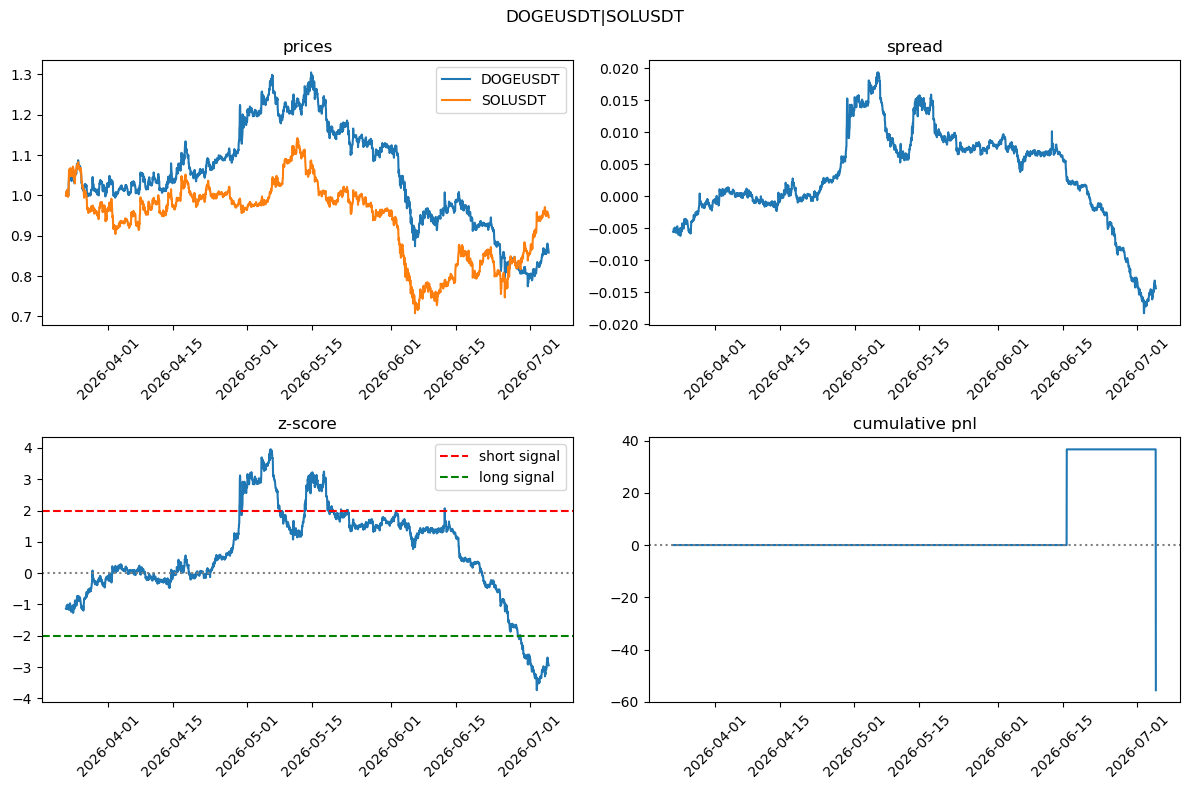

DOGEUSDT|ADAUSDT
cointegration p-value (train): 0.0479
total pnl: $-21.24 over 104 days
daily pnl: $-0.20/day
sharpe ratio: -1.87
max drawdown: -1.06%


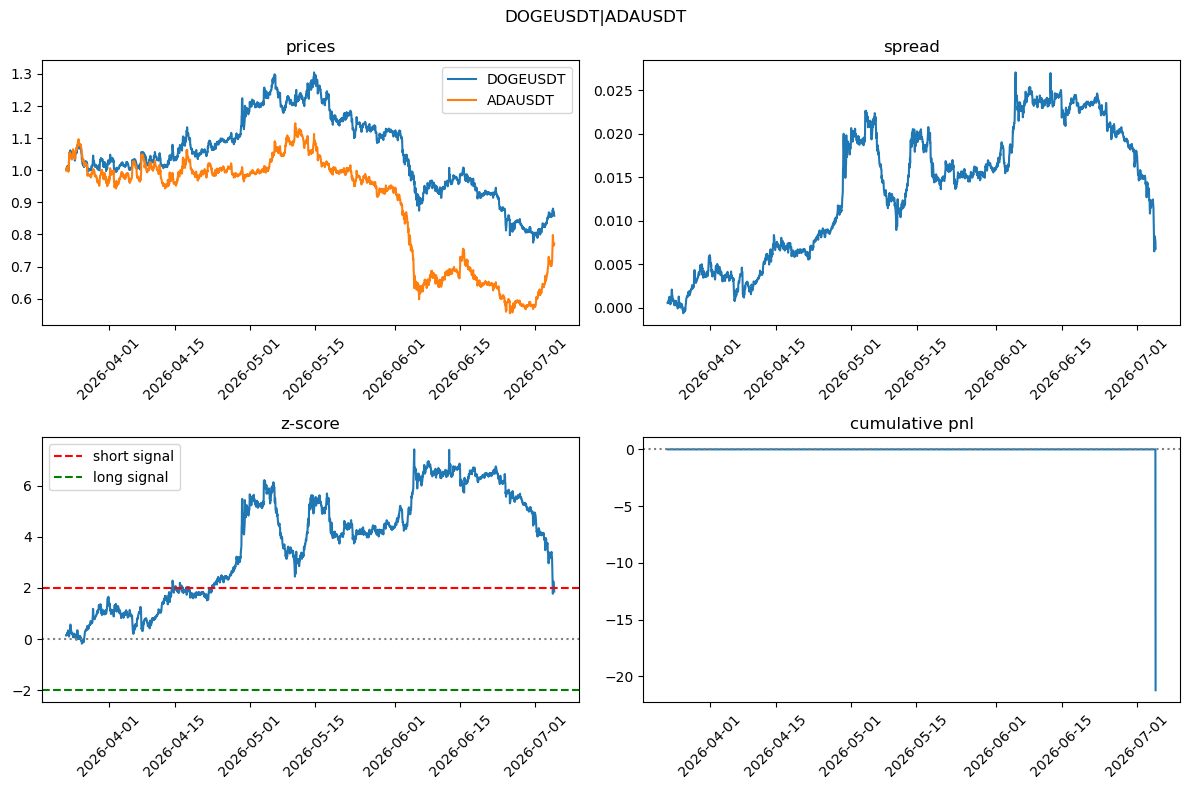

DOGEUSDT|XRPUSDT
cointegration p-value (train): 0.0006
total pnl: $26.37 over 104 days
daily pnl: $0.25/day
sharpe ratio: 1.87
max drawdown: 0.00%


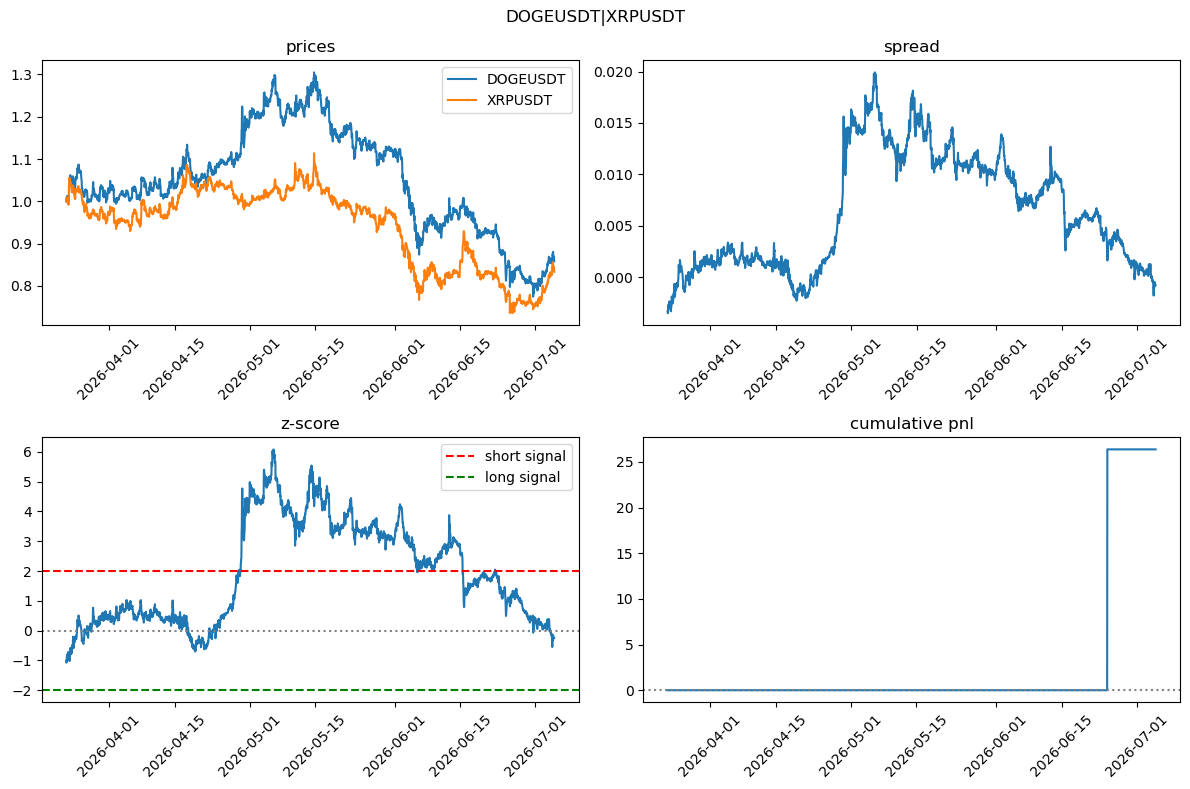

SOLUSDT|ETHUSDT
cointegration p-value (train): 0.0238
total pnl: $53.94 over 104 days
daily pnl: $0.52/day
sharpe ratio: 1.49
max drawdown: -1.22%


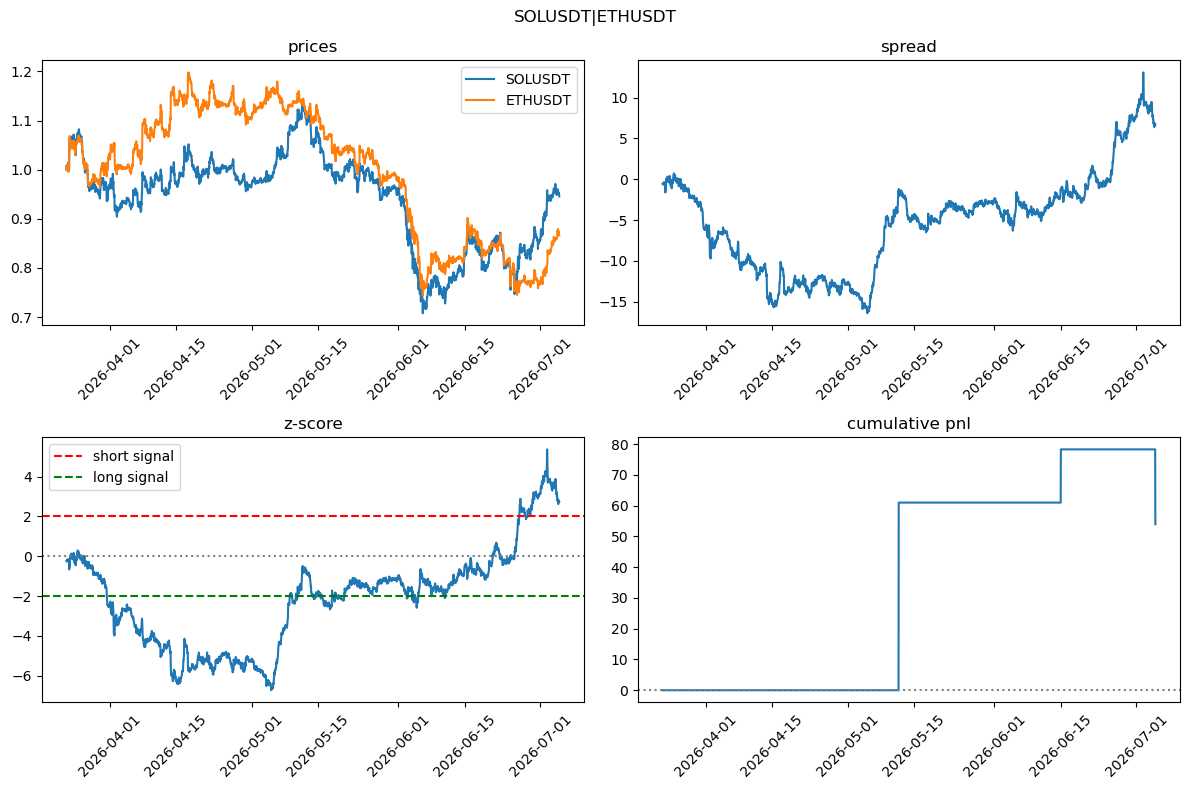

SOLUSDT|ADAUSDT
cointegration p-value (train): 0.0072
total pnl: $-137.78 over 104 days
daily pnl: $-1.32/day
sharpe ratio: -1.87
max drawdown: -6.89%


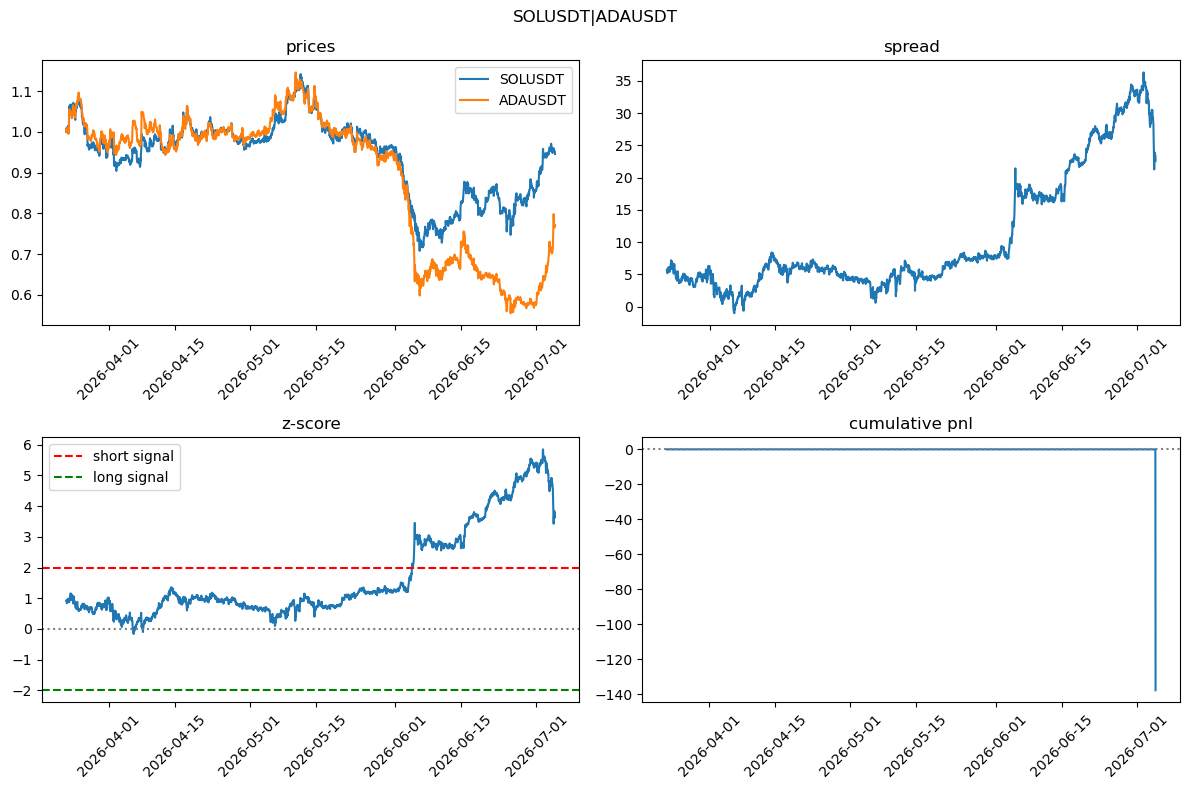

SOLUSDT|BTCUSDT
cointegration p-value (train): 0.0098
total pnl: $-124.69 over 104 days
daily pnl: $-1.20/day
sharpe ratio: -2.58
max drawdown: -6.23%


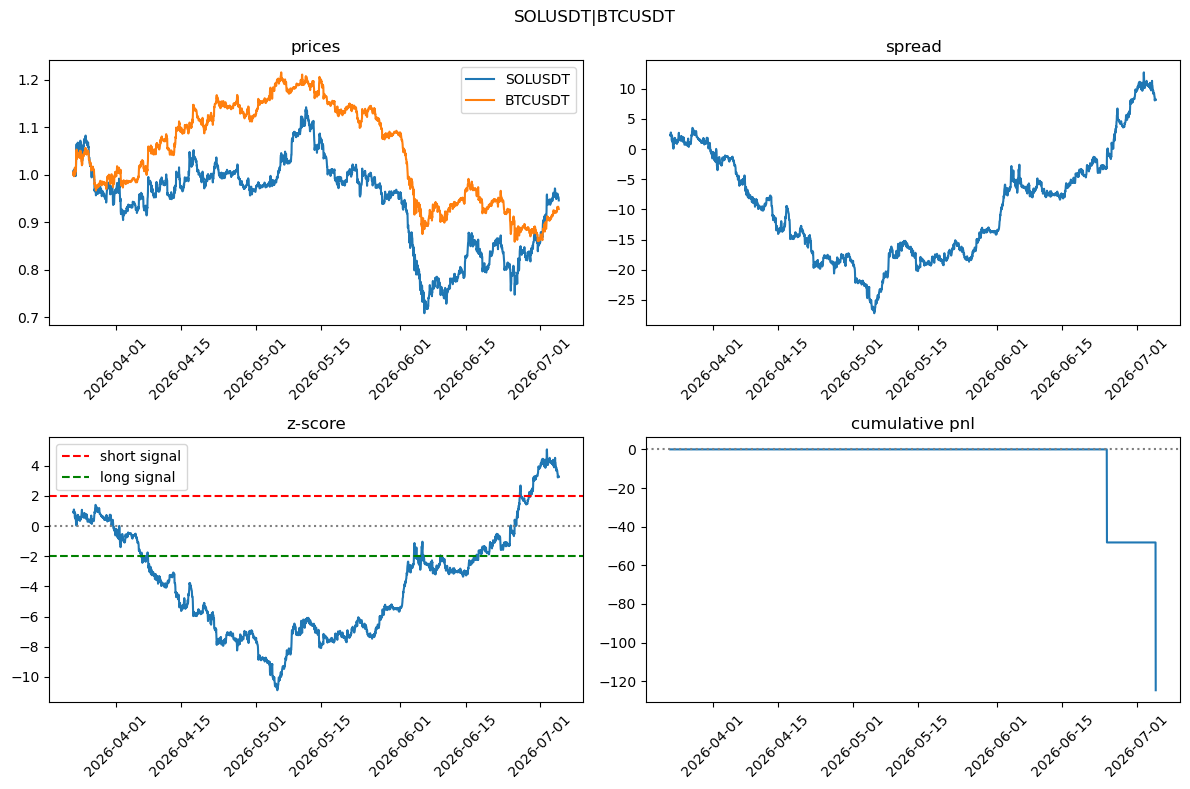

SOLUSDT|XRPUSDT
cointegration p-value (train): 0.0352
total pnl: $-93.59 over 104 days
daily pnl: $-0.90/day
sharpe ratio: -1.87
max drawdown: -4.68%


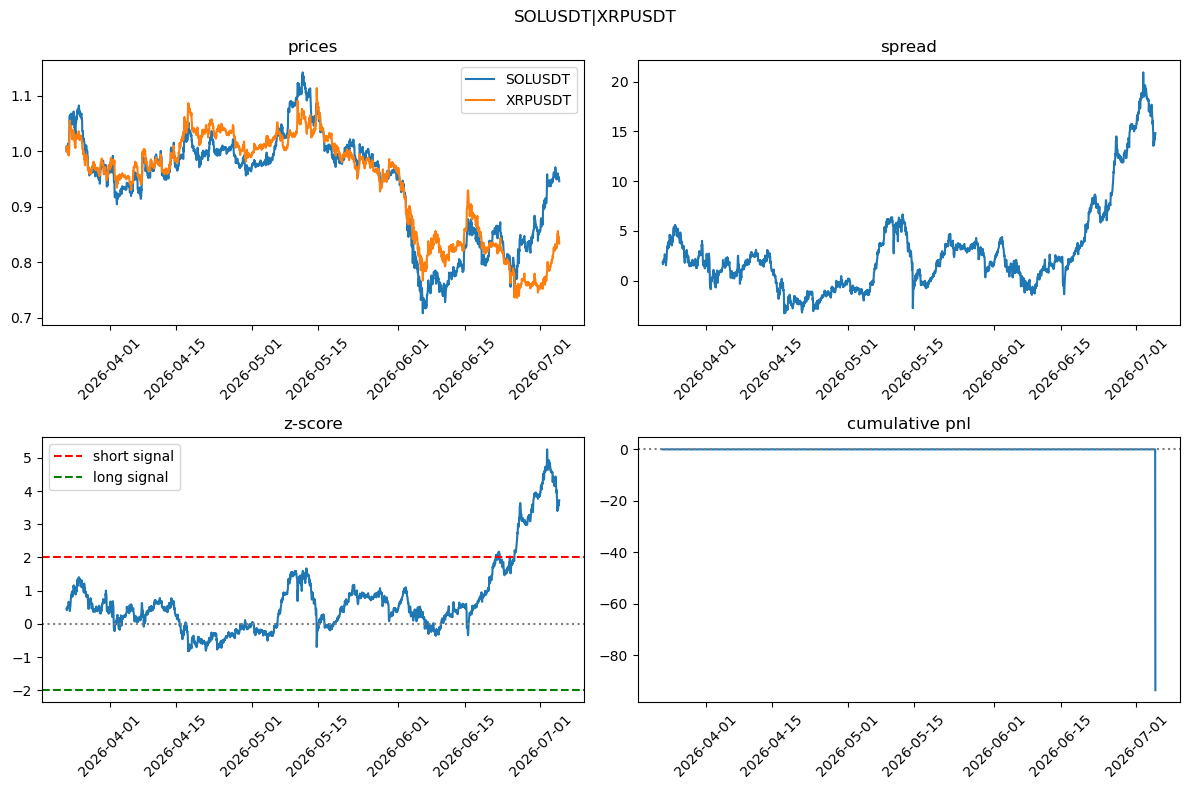

ETHUSDT|BTCUSDT
cointegration p-value (train): 0.0030
total pnl: $-40.18 over 104 days
daily pnl: $-0.39/day
sharpe ratio: -1.08
max drawdown: -3.35%


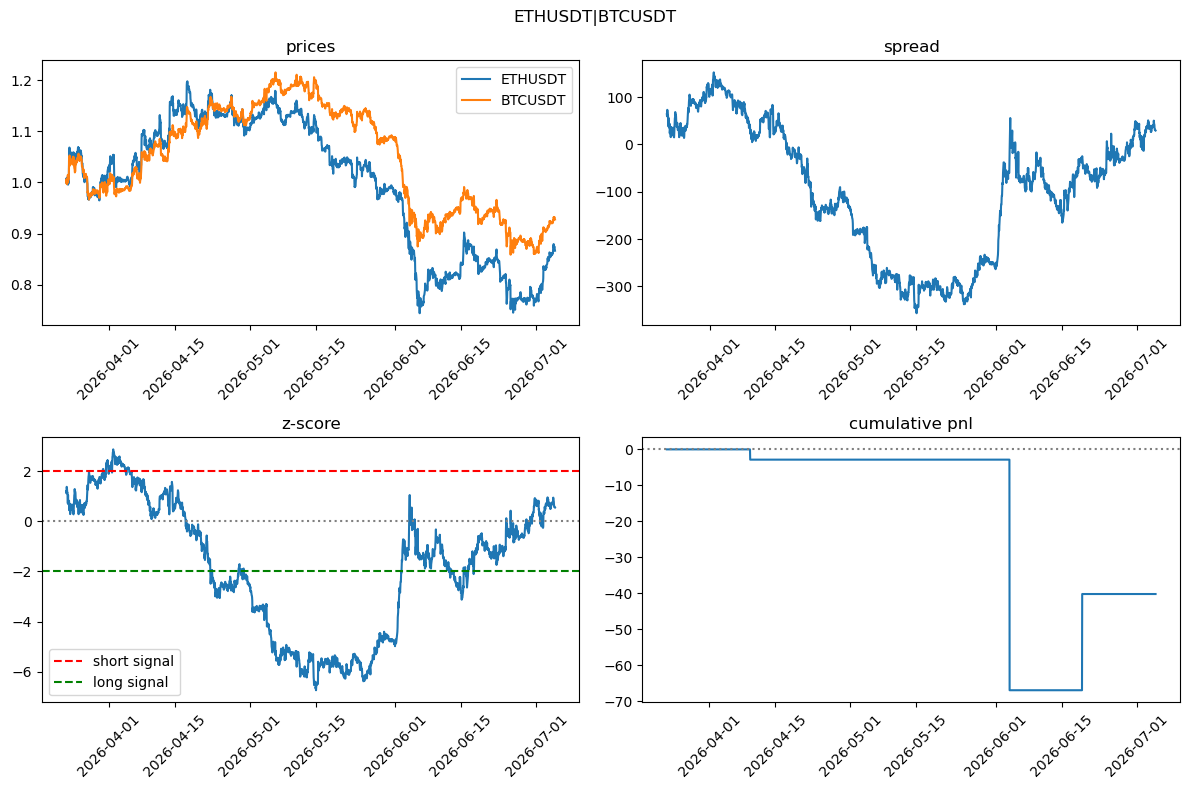

ETHUSDT|XRPUSDT
cointegration p-value (train): 0.0080
total pnl: $73.16 over 104 days
daily pnl: $0.70/day
sharpe ratio: 2.14
max drawdown: 0.00%


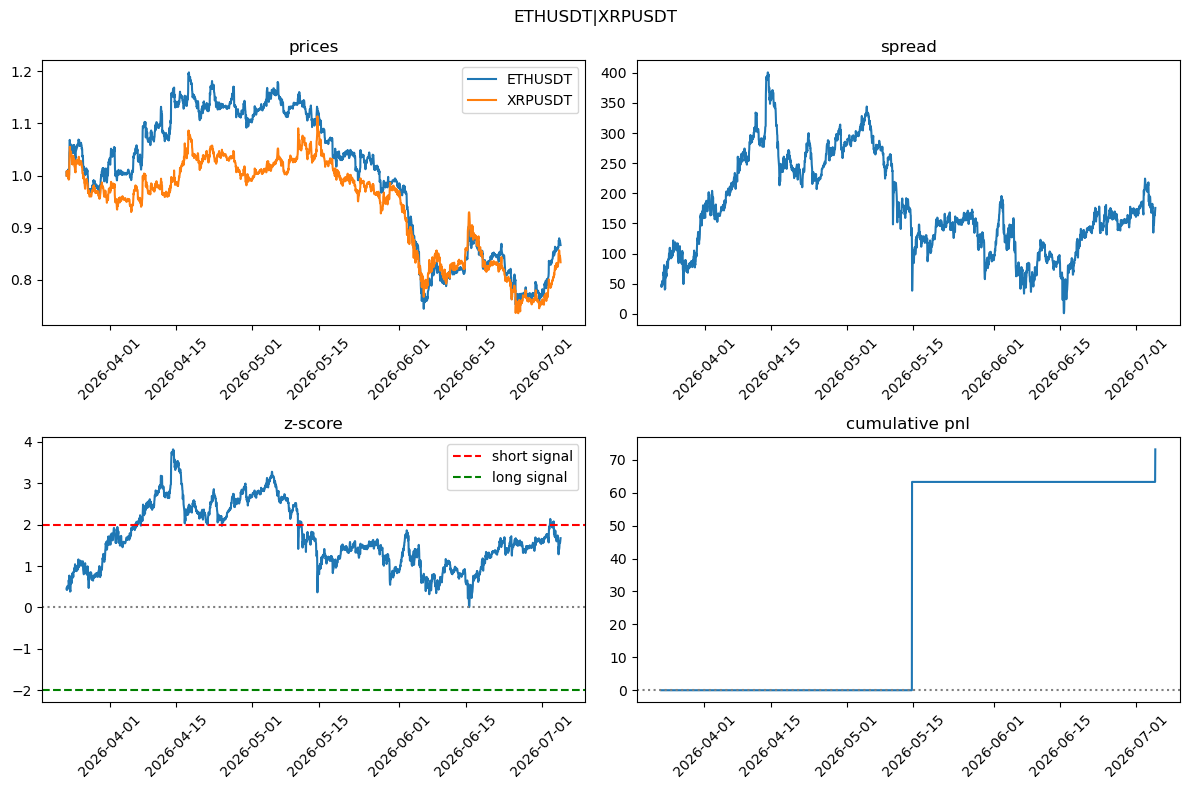

In [14]:
for ticker_a, ticker_b in zip(strong_filt['ticker_a'], strong_filt['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)